
# GRU-Based AQI Forecasting Model



In [1]:
try:
    import sklearn, tensorflow
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-learn', 'tensorflow'])


# AQI Forecasting — GRU Model
**Dataset:** Colaba_AQI_data.csv  
**Target:** Daily mean AQI  
**Model:** Stacked GRU Neural Network



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

print(f'TensorFlow version: {tf.__version__}')
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.21.0


## 1. Load & Preprocess Data

In [3]:
df = pd.read_csv('D:/AQI_Project/Data/Final/Colaba_AQI_daily_clean.csv', parse_dates=['Timestamp'])
df = df.set_index('Timestamp').sort_index()
df = df.drop(columns=['AQI_Category'], errors='ignore')
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce').interpolate(method='time')

daily = df.resample('D').mean().dropna(subset=['AQI'])
print(f'Daily records: {len(daily)}')

Daily records: 1826


## 2. Multivariate Setup & Normalization

In [4]:
from sklearn.preprocessing import StandardScaler
feature_cols = ['PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3']
target_col   = ['AQI']
daily[feature_cols + target_col] = daily[feature_cols + target_col].ffill().bfill()
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(daily[feature_cols])
y_scaled = scaler_y.fit_transform(daily[target_col])
data_scaled = __import__('numpy').hstack([X_scaled, y_scaled])
all_feature_cols = feature_cols + ['AQI']
print(data_scaled.shape)


(1826, 8)


## 3. Create Sequence Windows

In [5]:
SEQ_LEN = 30 

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(data_scaled, y_scaled.flatten(), SEQ_LEN)
print(f'Sequence shape: X={X_seq.shape}, y={y_seq.shape}')
print(f'Input shape per sample: (timesteps={SEQ_LEN}, features={len(feature_cols)})')

Sequence shape: X=(1796, 30, 8), y=(1796,)
Input shape per sample: (timesteps=30, features=7)


## 4. Train/Test Split

In [6]:
# Align with daily index (offset by SEQ_LEN)
dates = daily.index[SEQ_LEN:]
split_idx = np.searchsorted(dates, pd.Timestamp('2025-07-01'))

X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]
dates_test = dates[split_idx:]

# Further split train into train+val
val_idx = int(len(X_train) * 0.85)
X_tr, X_val = X_train[:val_idx], X_train[val_idx:]
y_tr, y_val = y_train[:val_idx], y_train[val_idx:]

print(f'Train={len(X_tr)}, Val={len(X_val)}, Test={len(X_test)}')

Train=1370, Val=242, Test=184


## 5. Build Stacked GRU Model

In [7]:

def build_gru(seq_len, n_features):
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=(seq_len, n_features)),
        Dropout(0.1),

        GRU(32),
        Dropout(0.1),

        Dense(16, activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mae'
    )

    return model

model = build_gru(SEQ_LEN, len(all_feature_cols))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,161 (94.38 KB)

 Trainable params: 24,161 (94.38 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train Model

In [8]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=1, min_lr=1e-5)
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.4453 - val_loss: 0.3106 - learning_rate: 0.0010
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3718 - val_loss: 0.3184 - learning_rate: 0.0010
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.3540 - val_loss: 0.3094 - learning_rate: 0.0010
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.3326 - val_loss: 0.3023 - learning_rate: 0.0010
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.3145 - val_loss: 0.2996 - learning_rate: 0.0010
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.3062 - val_loss: 0.2936 - learning_rate: 0.0010
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.3024 - val_loss: 0.2784 - learning_rate: 0.0010
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2994 - val_loss: 0.2832 - learning_rate: 0.0010
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2877 - val_loss: 0.2718 - learning_rate: 0.0010
Epoch 10/1

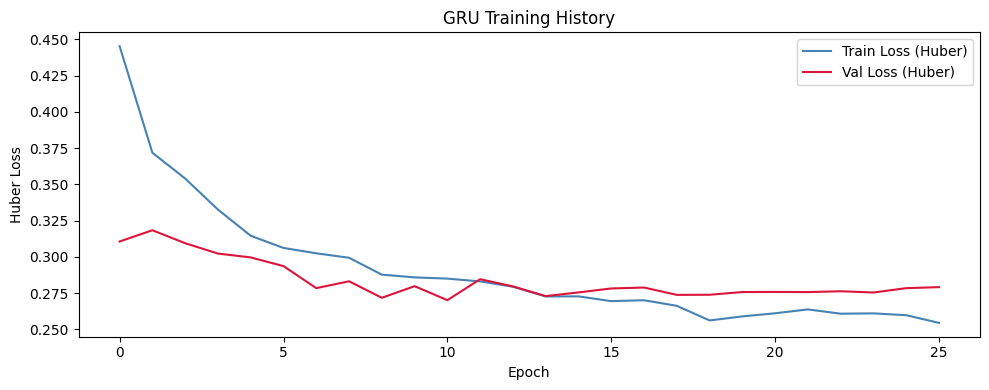

In [9]:
# Plot training history
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], label='Train Loss (Huber)', color='steelblue')
ax.plot(history.history['val_loss'], label='Val Loss (Huber)', color='crimson')
ax.set_title('GRU Training History')
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.legend()
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/gru_training_history_colaba.png', dpi=150)
plt.show()

## 7. Forecast & Evaluation

In [10]:
# Direct (one-step-ahead for each test window using actual data)
pred_scaled = model.predict(X_test, verbose=0)
pred_aqi = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
actual_aqi = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(actual_aqi, pred_aqi))
mae  = mean_absolute_error(actual_aqi, pred_aqi)
mape = np.mean(np.abs((actual_aqi - pred_aqi) / actual_aqi)) * 100

print(f'GRU Performance on Test Set:')
print(f'  RMSE : {rmse:.2f}')
print(f'  MAE  : {mae:.2f}')
print(f'  MAPE : {mape:.2f}%')

GRU Performance on Test Set:
  RMSE : 15.04
  MAE  : 10.32
  MAPE : 16.54%


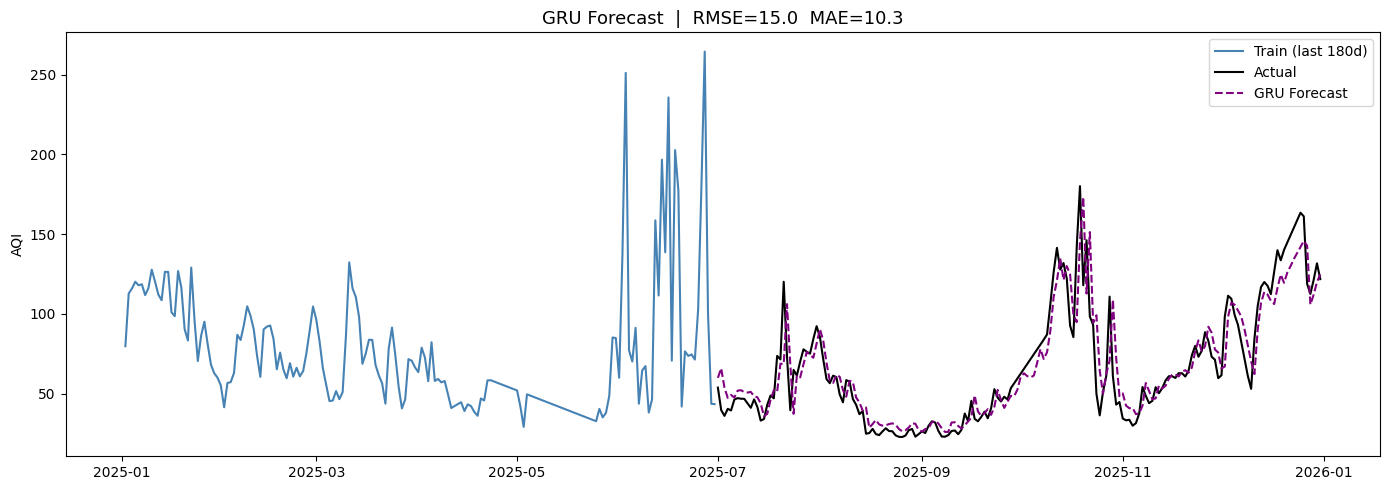

In [11]:
# Get last 180 days of training for context
train_aqi_orig = scaler_y.inverse_transform(y_train[-180:].reshape(-1, 1)).flatten()
train_dates    = dates[split_idx-180:split_idx]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_dates, train_aqi_orig, label='Train (last 180d)', color='steelblue')
ax.plot(dates_test, actual_aqi, label='Actual', color='black', linewidth=1.5)
ax.plot(dates_test, pred_aqi, label='GRU Forecast', color='purple', linestyle='--')
ax.set_title(f'GRU Forecast  |  RMSE={rmse:.1f}  MAE={mae:.1f}', fontsize=13)
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/gru_forecast_colaba.png', dpi=150)
plt.show()

## 8. Residual Analysis

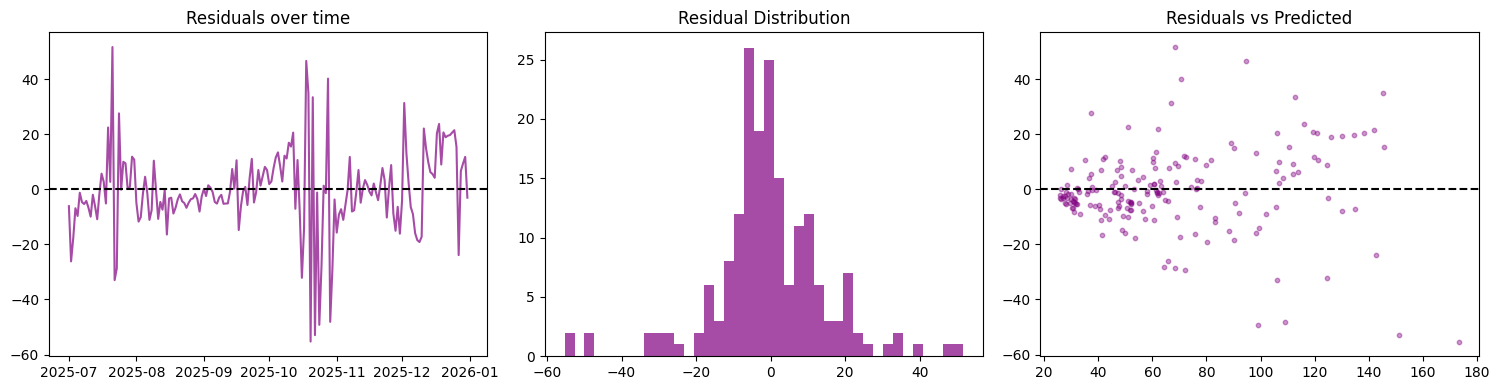

In [12]:
residuals = actual_aqi - pred_aqi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(dates_test, residuals, color='purple', alpha=0.7)
axes[0].axhline(0, linestyle='--', color='black')
axes[0].set_title('Residuals over time')
axes[1].hist(residuals, bins=40, color='purple', alpha=0.7)
axes[1].set_title('Residual Distribution')
axes[2].scatter(pred_aqi, residuals, alpha=0.4, color='purple', s=10)
axes[2].axhline(0, linestyle='--', color='black')
axes[2].set_title('Residuals vs Predicted')
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/gru_residuals_colaba.png', dpi=150)
plt.show()

## 8. Classification Metrics & Confusion Matrix
Converting continuous AQI forecasts into discrete AQI categories to evaluate classification performance (Accuracy, Precision, Recall).

Classification Metrics for AQI Categories:
Accuracy:  0.7880
Precision: 0.7996 (Weighted)
Recall:    0.7880 (Weighted)

Classification Report:
              precision    recall  f1-score   support

        Good       0.88      0.76      0.82        80
Satisfactory       0.69      0.80      0.74        70
    Moderate       0.82      0.82      0.82        34

    accuracy                           0.79       184
   macro avg       0.80      0.80      0.79       184
weighted avg       0.80      0.79      0.79       184



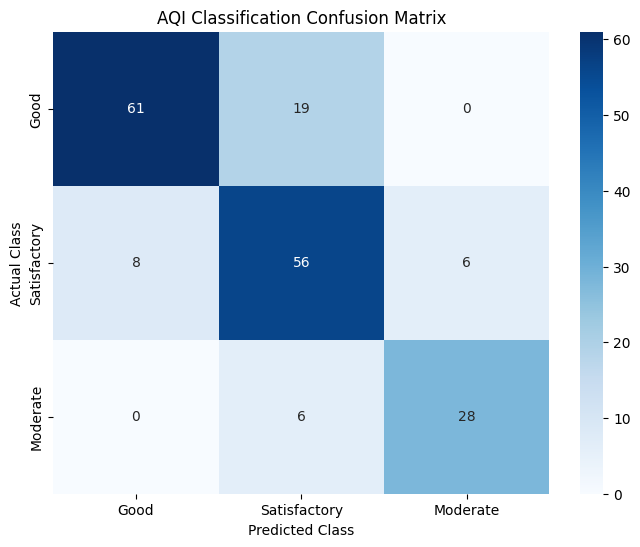

In [13]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Define AQI categories based on Indian standards
def categorize_aqi(aqi_values):
    categories = []
    for val in aqi_values:
        if val <= 50:
            categories.append('Good')
        elif val <= 100:
            categories.append('Satisfactory')
        elif val <= 200:
            categories.append('Moderate')
        elif val <= 300:
            categories.append('Poor')
        elif val <= 400:
            categories.append('Very Poor')
        else:
            categories.append('Severe')
    return np.array(categories)

# Ensure values are flattened arrays
y_true_cont = np.array(actual_aqi).flatten()
y_pred_cont = np.array(pred_aqi).flatten()

# Convert continuous predictions to discrete AQI classes
y_true_class = categorize_aqi(y_true_cont)
y_pred_class = categorize_aqi(y_pred_cont)

# Labels for standard Indian AQI
labels = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
# Filter labels to only those present in the actual or predicted to avoid empty rows/cols if desired
# But keeping all labels shows a full matrix
present_labels = [l for l in labels if l in y_true_class or l in y_pred_class]

# Calculate Metrics
acc = accuracy_score(y_true_class, y_pred_class)
# weighted average for precision and recall since it's multiclass
prec = precision_score(y_true_class, y_pred_class, average='weighted', zero_division=0)
rec = recall_score(y_true_class, y_pred_class, average='weighted', zero_division=0)

print(f"Classification Metrics for AQI Categories:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f} (Weighted)")
print(f"Recall:    {rec:.4f} (Weighted)\n")

print("Classification Report:")
print(classification_report(y_true_class, y_pred_class, labels=present_labels, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true_class, y_pred_class, labels=present_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=present_labels, yticklabels=present_labels)
plt.title('AQI Classification Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

os.makedirs('images', exist_ok=True)
plt.savefig('images/gru_confusion_matrix_colaba.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Save model weights
model.save('saved_models/gru_colaba_aqi_model.keras')
print('Model saved as gru_colaba_aqi_model.keras')

Model saved as gru_colaba_aqi_model.keras
